# ColocVolume — usage example
> Individual-subject visualisation of SimNIBS e-fields via `simnibs_reader` + `ColocVolume`.

In [20]:
import sys

from pathlib import Path
import matplotlib.pyplot as plt
sys.path.insert(0, '/Users/hippolyte.dreyfus/Documents/simnibs-reader')
import simnibs_reader as snr

sys.path.insert(0, "/Users/hippolyte.dreyfus/Documents/simnibs-analyze/simnibs_analyze/core")
from visualizer import ColocVolume

## 0 — Paths (edit these)

In [11]:
SIM_DIR = Path('/Users/hippolyte.dreyfus/Documents/0-tmp-simnibs-output/simulation_simulation_fef_hemianotacs_5626899c')
SEG_DIR = Path('/Users/hippolyte.dreyfus/Documents/0-tmp-simnibs-output/m2m_0001')
LESION  = None #Path('/path/to/T1_brain_lesion.nii.gz')  # set to None to skip

ROI_COORDS = [20, -8, 54]
ROI_RADIUS = 10

## 1 — Load simulation + segmentation

In [12]:
sim = snr.simulation(SIM_DIR)
seg = snr.segmentation(SEG_DIR)
sim.set_segmentation(seg)

print(sim)
print(sim.available_fields)

SimulationResult('/Users/hippolyte.dreyfus/Documents/0-tmp-simnibs-output/simulation_simulation_fef_hemianotacs_5626899c')
{'mni': [PosixPath('/Users/hippolyte.dreyfus/Documents/0-tmp-simnibs-output/simulation_simulation_fef_hemianotacs_5626899c/mni_volumes/0002_TDCS_1_scalar_MNI_E.nii.gz'), PosixPath('/Users/hippolyte.dreyfus/Documents/0-tmp-simnibs-output/simulation_simulation_fef_hemianotacs_5626899c/mni_volumes/0002_TDCS_1_scalar_MNI_J.nii.gz'), PosixPath('/Users/hippolyte.dreyfus/Documents/0-tmp-simnibs-output/simulation_simulation_fef_hemianotacs_5626899c/mni_volumes/0002_TDCS_1_scalar_MNI_magnE.nii.gz'), PosixPath('/Users/hippolyte.dreyfus/Documents/0-tmp-simnibs-output/simulation_simulation_fef_hemianotacs_5626899c/mni_volumes/0002_TDCS_1_scalar_MNI_magnE_extra_fef_cleaned.nii.gz'), PosixPath('/Users/hippolyte.dreyfus/Documents/0-tmp-simnibs-output/simulation_simulation_fef_hemianotacs_5626899c/mni_volumes/0002_TDCS_1_scalar_MNI_magnE_extra_fef_masked.nii.gz'), PosixPath('/User

## 2 — Extract ROI and post-process

In [13]:
efield = sim.magnE  # MNI space
# efield = sim.magnE_native  # subject space

roi = efield.get_roi(coords=ROI_COORDS, radius=ROI_RADIUS)
print(roi)
print(roi.stats())

ROIResult(n_voxels=4169, status=raw)
{'mean': 0.02831356495371992, 'median': 0.0, 'std': 0.040429579403140965, 'min': 0.0, 'max': 0.12653875350952148, 'p5': 0.0, 'p95': 0.10656846761703491, 'n_voxels': 4169, 'volume_mm3': 4169.0}


In [14]:
cleaned = roi.postprocess(
    smooth_fwhm    = 2.0,
    outlier_method = 'iqr',
    portion        = 0.95,
)
print(cleaned)
print(cleaned.stats())

ROIResult(n_voxels=4169, status=cleaned)
{'mean': 0.026944194776529644, 'median': 0.00824781320989132, 'std': 0.03215997320155676, 'min': 0.0, 'max': 0.09698855876922607, 'p5': 6.154430565175062e-08, 'p95': 0.08863077312707901, 'n_voxels': 4169, 'volume_mm3': 4169.0}


## 3 — Build ColocVolume

In [ ]:
vol = ColocVolume()

vol.add_layer(
    seg.t1,
    role    = 'background',
    cmap    = 'gray',
    opacity = 1,
    label   = 'T1',
)

# vol.add_layer(
#     cleaned,          # ROIResult resolved via .mask_img
#     role    = 'stat_map',
#     cmap    = 'Blues',
#     opacity = 0,
#     label   = 'magnE-cleaned',
#     # clim  = (0.0, 0.15),  # uncomment to fix colour scale
# )

vol.add_layer(
    sim.magnE_native,          # .filter_tissue('Gray-Matter') we should be able to do this ?! 
    role    = 'stat_map',
    cmap    = 'Blues',
    opacity = 1,
    label   = 'magnE-cleaned',
    # clim  = (0.0, 0.15),  # uncomment to fix colour scale
)

# if LESION is not None and LESION.exists():
#     vol.add_layer(
#         LESION,
#         role    = 'overlay',
#         color   = 'magenta',
#         opacity = 0.4,
#         label   = 'lesion',
#     )

print(vol)

AttributeError: 'EFieldAccessor' object has no attribute 'filter_tissue'

## 4a — 2-D ortho slices (nilearn)

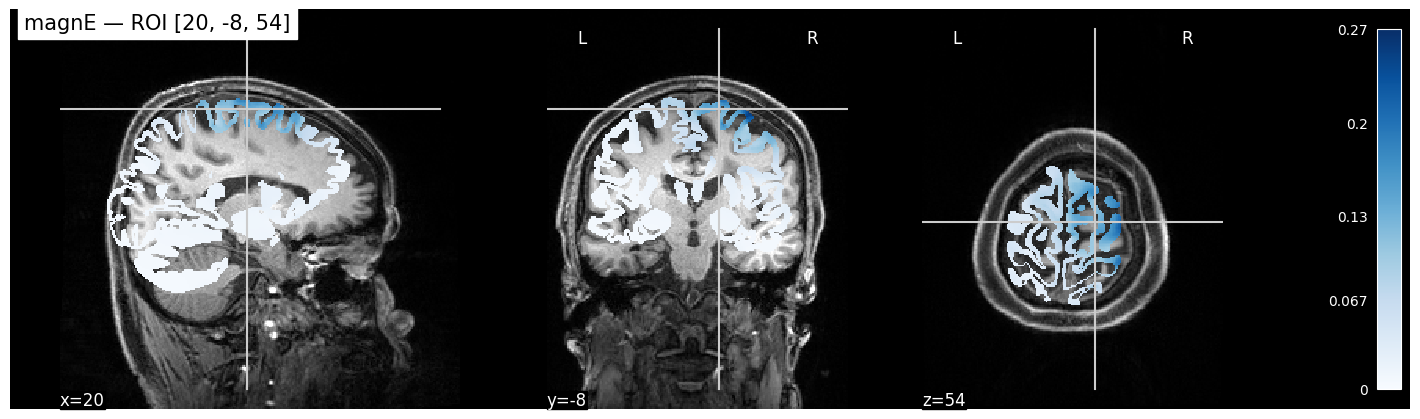

In [33]:
vol.plot_slices(
    cut_coords   = ROI_COORDS,
    display_mode = 'ortho',
    title        = f'magnE — ROI {ROI_COORDS}',
)

## 4b — 2-D parallel slices (nilearn)

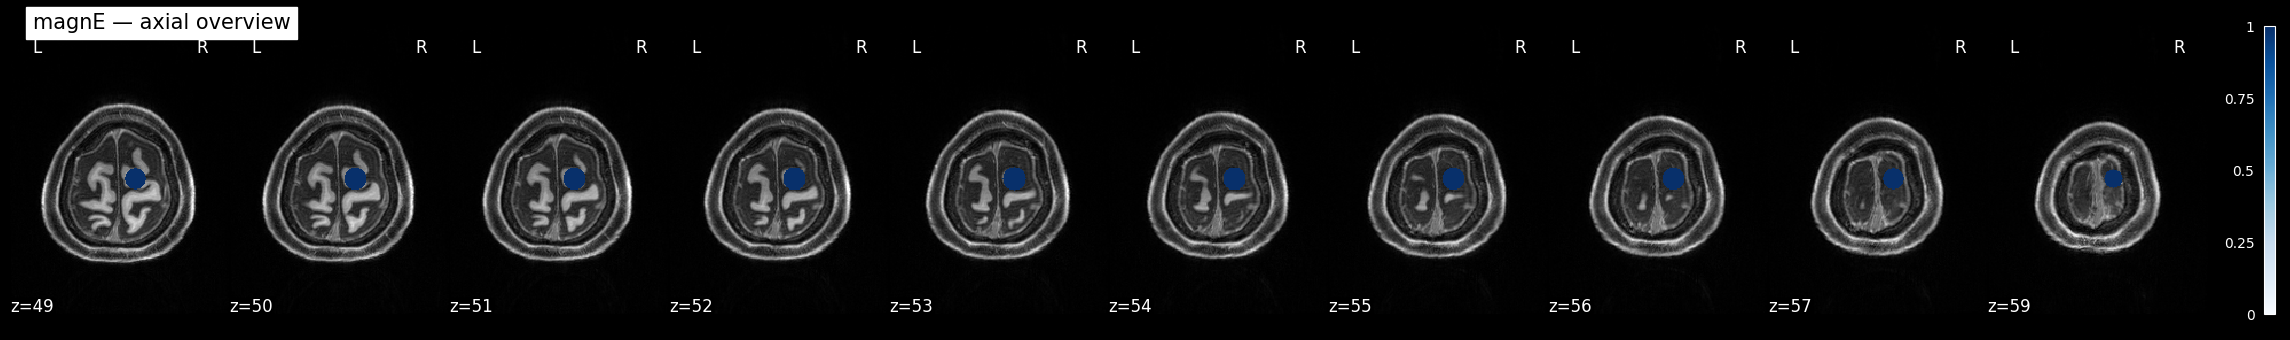

In [8]:
vol.plot_parallel_slices(axis='z', n_slices=10, title='magnE — axial overview')

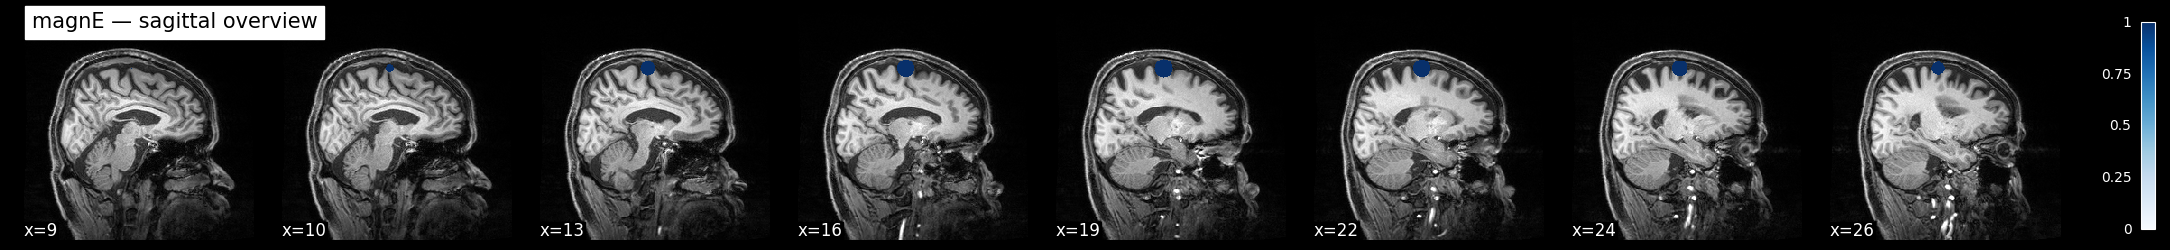

In [32]:
vol.plot_parallel_slices(axis='x', n_slices=8, title='magnE — sagittal overview')

## 5 — 3-D offscreen render (PyVista)

In [21]:
frame = vol.plot_3d(camera_position='xy')
print(f'Rendered frame shape: {frame.shape}')



Rendered frame shape: (768, 1024, 3)


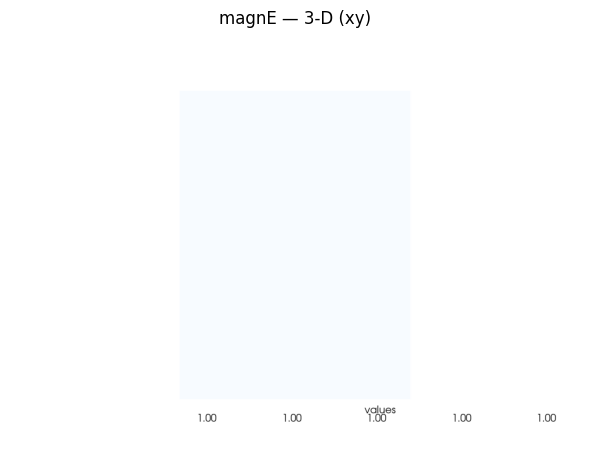

In [24]:
plt.figure(figsize=(6, 6))
plt.imshow(frame)
plt.axis('off')
plt.title('magnE — 3-D (xy)')
plt.tight_layout()
plt.show()

## 6 — Interactive 3-D (PyVista live window)

In [ ]:
# Blocks until the window is closed
vol.view_interactive(camera_position='xy', title='magnE — interactive')

## 7 — Tissue-filtered ROI (Gray-Matter only)

In [35]:
# Requires sim.set_segmentation(seg) done above
roi_gm = (
    sim.magnE_native
       .get_roi(coords=ROI_COORDS, radius=10)
       .filter_tissue('Gray-Matter')
)
print(roi_gm)
print(roi_gm.stats())

ROIResult(n_voxels=1395, status=raw)
{'mean': 0.06329111695610067, 'median': 0.0, 'std': 0.06654528548291952, 'min': 0.0, 'max': 0.19282953441143036, 'p5': 0.0, 'p95': 0.14876332730054856, 'n_voxels': 1395, 'volume_mm3': 1395.0}


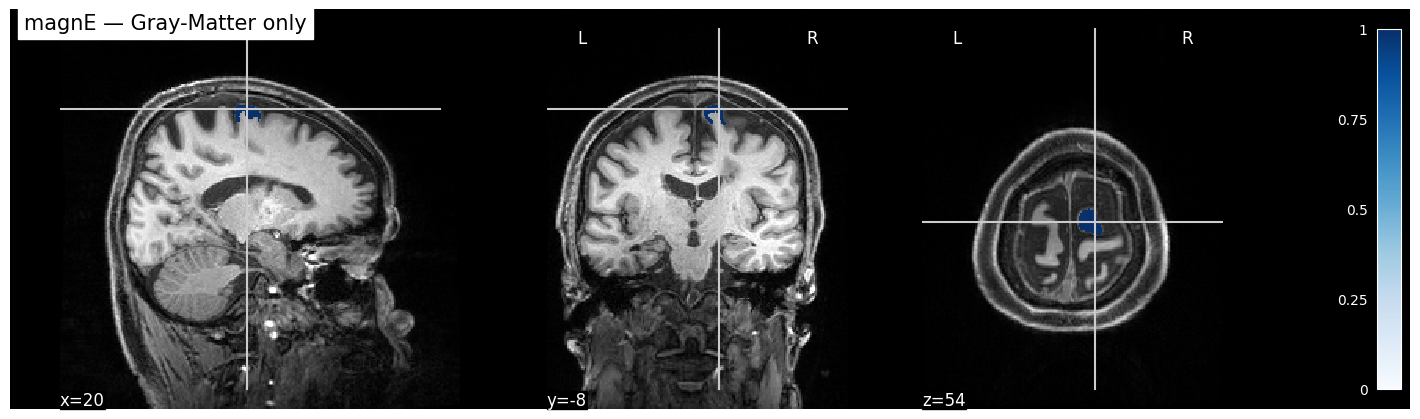

In [37]:
vol_gm = ColocVolume()
vol_gm.add_layer(seg.t1,  role='background', cmap='gray', opacity=0.15, label='T1')
vol_gm.add_layer(roi_gm,  role='stat_map',   cmap='Blues',  opacity=1.0,  label='magnE-GM')

vol_gm.plot_slices(cut_coords=ROI_COORDS, title='magnE — Gray-Matter only')

## 8 — Cohort colour scale (cross-subject normalisation)
> Coming in next phase — use `vol.set_clim('magnE-cleaned', vmin, vmax)` with a pre-computed scale.

In [ ]:
# Example: fix scale from a pre-computed cohort range
# vol.set_clim('magnE-cleaned', vmin=0.0, vmax=0.15)
# vol.plot_slices(cut_coords=ROI_COORDS)